In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv("students.csv")

# Print the first 5 rows
print("--- First 5 Rows ---")
display(df.head()) # Use display() in Notebooks for a pretty table!

# Print the shape and data types
print(f"\nDataset Shape: {df.shape}")
print("\nColumn Data Types:")
print(df.dtypes)

--- First 5 Rows ---


,name,math,science,english,history,pe,attendance_pct,study_hours_per_day,passed
0,Alice,88,92,76,80,95,92,4.5,1
1,Bob,42,55,48,50,60,65,1.2,0
2,Charlie,75,70,80,68,88,85,3.0,1
3,Diana,95,98,91,89,97,98,6.0,1
4,Eve,38,42,50,45,55,58,0.8,0



Dataset Shape: (15, 9)

Column Data Types:
name                       str
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    float64
passed                   int64
dtype: object


In [2]:
# Print summary statistics (mean, min, max, std)
print("\n--- Summary Statistics ---")
print(df.describe())


--- Summary Statistics ---
            math    science    english    history         pe  attendance_pct  \
count  15.000000  15.000000  15.000000  15.000000  15.000000       15.000000   
mean   65.000000  66.733333  66.200000  63.400000  74.800000       75.800000   
std    20.060622  18.967893  17.773174  16.936014  16.657045       14.722189   
min    30.000000  35.000000  40.000000  28.000000  45.000000       50.000000   
25%    51.500000  53.500000  49.000000  53.500000  61.000000       63.500000   
50%    65.000000  65.000000  70.000000  62.000000  75.000000       78.000000   
75%    80.000000  77.000000  81.000000  73.500000  89.000000       86.500000   
max    95.000000  98.000000  91.000000  92.000000  97.000000       98.000000   

       study_hours_per_day     passed  
count            15.000000  15.000000  
mean              2.893333   0.600000  
std               1.658944   0.507093  
min               0.500000   0.000000  
25%               1.650000   0.000000  
50%        

In [3]:
# Count of students who passed and failed
print("\n--- Pass (1) vs Fail (0) Count ---")
print(df['passed'].value_counts())


--- Pass (1) vs Fail (0) Count ---
passed
1    9
0    6
Name: count, dtype: int64


In [4]:
# Define the columns we want to average
subject_cols = ['math', 'science', 'english', 'history', 'pe']

# Averages for students who passed (1)
passing_avg = df[df['passed'] == 1][subject_cols].mean()
print("\n--- Average Scores for Passing Students ---")
print(passing_avg)

# Averages for students who failed (0)
failing_avg = df[df['passed'] == 0][subject_cols].mean()
print("\n--- Average Scores for Failing Students ---")
print(failing_avg)


--- Average Scores for Passing Students ---
math       78.222222
science    78.555556
english    79.111111
history    73.444444
pe         86.000000
dtype: float64

--- Average Scores for Failing Students ---
math       45.166667
science    49.000000
english    46.833333
history    48.333333
pe         58.000000
dtype: float64


In [5]:
# 1. Create a temporary column for the student's personal average
df['overall_avg'] = df[subject_cols].mean(axis=1)

# 2. Find the index of the highest average
top_student_idx = df['overall_avg'].idxmax()

# 3. Pull that student's row
top_student = df.loc[top_student_idx]

print(f"\n--- Student with Highest Overall Average ---")
print(f"Name: {top_student['name']}")
print(f"Average Score: {top_student['overall_avg']:.2f}")


--- Student with Highest Overall Average ---
Name: Diana
Average Score: 94.00


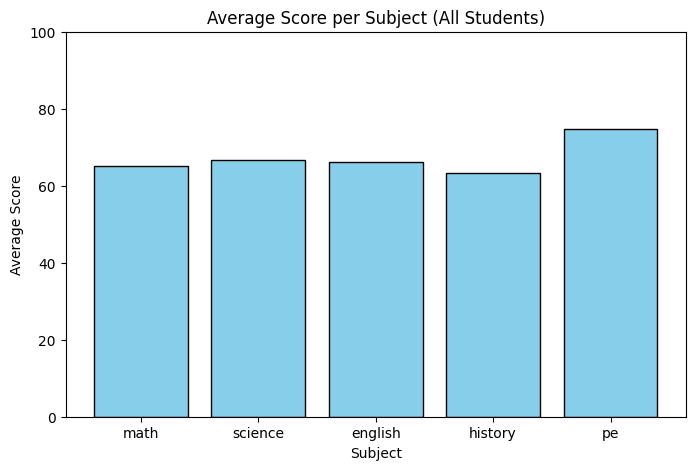

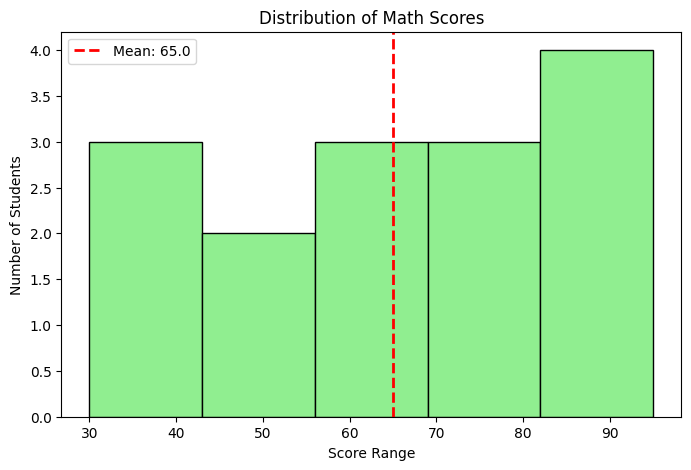

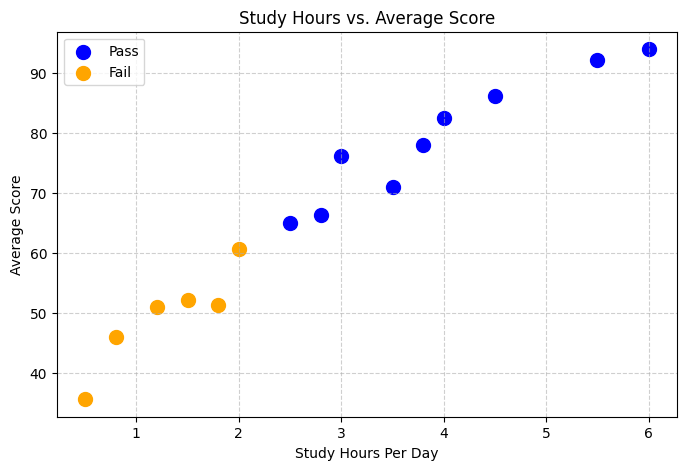

C:\Users\Shamith\AppData\Local\Temp\ipykernel_33240\211689147.py:67: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([pass_attendance, fail_attendance], labels=['Pass', 'Fail'])


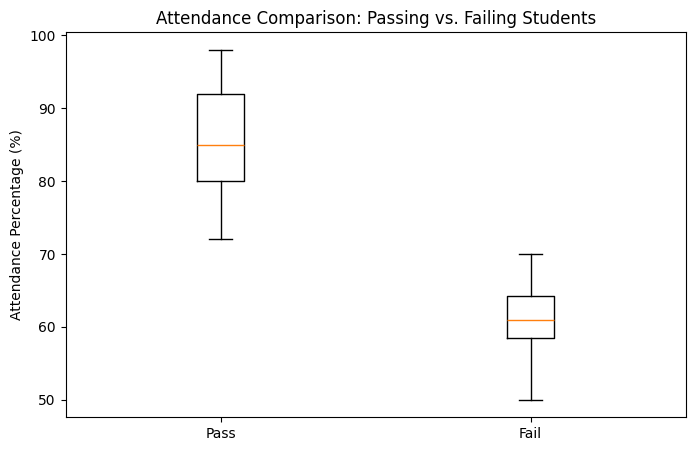

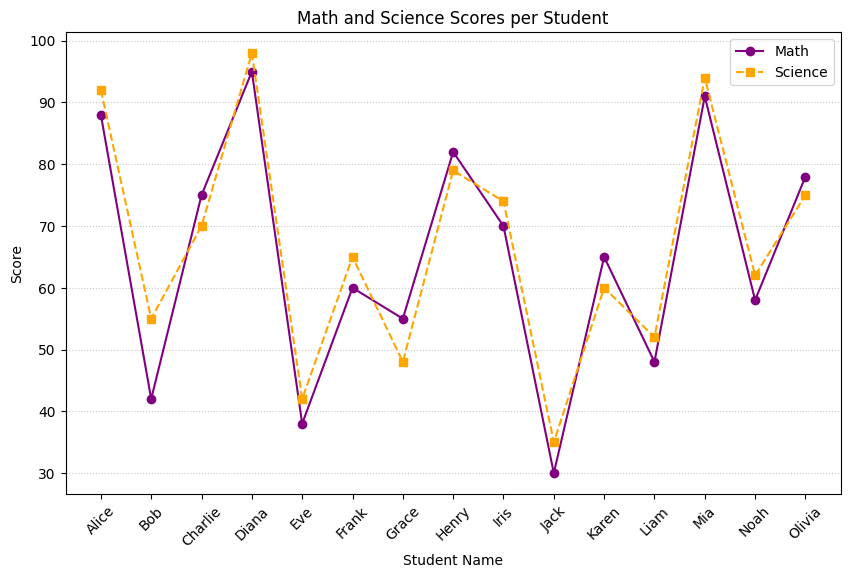

In [6]:
import matplotlib.pyplot as plt
import pandas as pd

# Create the average column first as requested
subject_cols = ['math', 'science', 'english', 'history', 'pe']
df['avg_score'] = df[subject_cols].mean(axis=1)



plt.figure(figsize=(8, 5))
subject_means = df[subject_cols].mean()

plt.bar(subject_cols, subject_means, color='skyblue', edgecolor='black')
plt.title('Average Score per Subject (All Students)')
plt.xlabel('Subject')
plt.ylabel('Average Score')
plt.ylim(0, 100) # Sets the scale from 0 to 100

plt.savefig('plot1_bar.png')
plt.show()




plt.figure(figsize=(8, 5))
plt.hist(df['math'], bins=5, color='lightgreen', edgecolor='black')

# Add the vertical dashed line for the mean
math_mean = df['math'].mean()
plt.axvline(math_mean, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {math_mean:.1f}')

plt.title('Distribution of Math Scores')
plt.xlabel('Score Range')
plt.ylabel('Number of Students')
plt.legend()

plt.savefig('plot2_histogram.png')
plt.show()



plt.figure(figsize=(8, 5))

# Plot Passing and Failing groups separately
pass_df = df[df['passed'] == 1]
fail_df = df[df['passed'] == 0]

plt.scatter(pass_df['study_hours_per_day'], pass_df['avg_score'], color='blue', label='Pass', s=100)
plt.scatter(fail_df['study_hours_per_day'], fail_df['avg_score'], color='orange', label='Fail', s=100)

plt.title('Study Hours vs. Average Score')
plt.xlabel('Study Hours Per Day')
plt.ylabel('Average Score')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.savefig('plot3_scatter.png')
plt.show()



plt.figure(figsize=(8, 5))

pass_attendance = df[df['passed'] == 1]['attendance_pct'].tolist()
fail_attendance = df[df['passed'] == 0]['attendance_pct'].tolist()

plt.boxplot([pass_attendance, fail_attendance], labels=['Pass', 'Fail'])

plt.title('Attendance Comparison: Passing vs. Failing Students')
plt.ylabel('Attendance Percentage (%)')

plt.savefig('plot4_box.png')
plt.show()



plt.figure(figsize=(10, 6))

plt.plot(df['name'], df['math'], marker='o', linestyle='-', label='Math', color='purple')
plt.plot(df['name'], df['science'], marker='s', linestyle='--', label='Science', color='orange')

plt.title('Math and Science Scores per Student')
plt.xlabel('Student Name')
plt.ylabel('Score')
plt.xticks(rotation=45) # Rotates names so they don't overlap
plt.legend()
plt.grid(axis='y', linestyle=':', alpha=0.7)

plt.savefig('plot5_line.png')
plt.show()

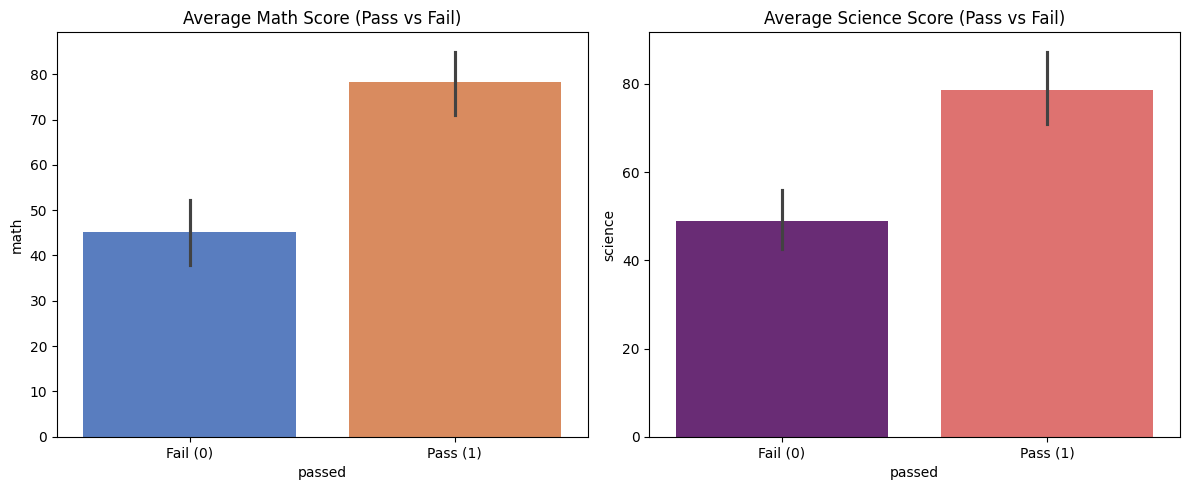

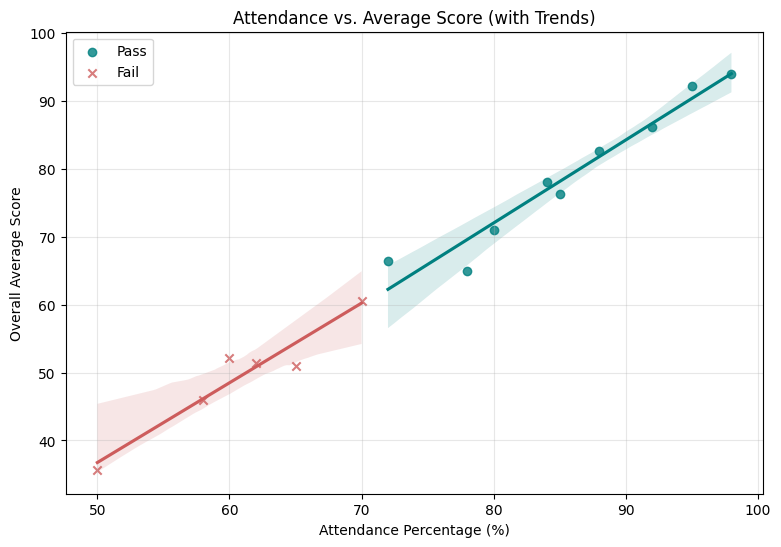

'\nExperience Comparison:\nMatplotlib felt more like building from scratch; I had to manually filter data \nand set colors for every group. Seaborn was much easier for statistical \ntasks—like adding the regression lines—because it handles the math and \nstyling automatically in a single function call.\n'

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a figure with 2 subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Math Scores (Updated with hue and legend=False)
sns.barplot(data=df, x='passed', y='math', hue='passed', ax=ax1, palette='muted', legend=False)
ax1.set_title('Average Math Score (Pass vs Fail)')
# The new way to change labels safely:
ax1.set_xticks([0, 1]) 
ax1.set_xticklabels(['Fail (0)', 'Pass (1)'])

# Plot 2: Science Scores (Updated with hue and legend=False)
sns.barplot(data=df, x='passed', y='science', hue='passed', ax=ax2, palette='magma', legend=False)
ax2.set_title('Average Science Score (Pass vs Fail)')
ax2.set_xticks([0, 1])
ax2.set_xticklabels(['Fail (0)', 'Pass (1)'])

plt.tight_layout()
plt.savefig('seaborn_task1_bars.png')
plt.show()



plt.figure(figsize=(9, 6))

# Plot regression for Passing students
sns.regplot(data=df[df['passed']==1], x='attendance_pct', y='avg_score', 
            label='Pass', color='teal', marker='o')

# Plot regression for Failing students
sns.regplot(data=df[df['passed']==0], x='attendance_pct', y='avg_score', 
            label='Fail', color='indianred', marker='x')

plt.title('Attendance vs. Average Score (with Trends)')
plt.xlabel('Attendance Percentage (%)')
plt.ylabel('Overall Average Score')
plt.legend()
plt.grid(True, alpha=0.3)

plt.savefig('seaborn_task2_regression.png')
plt.show()


"""
Experience Comparison:
Matplotlib felt more like building from scratch; I had to manually filter data 
and set colors for every group. Seaborn was much easier for statistical 
tasks—like adding the regression lines—because it handles the math and 
styling automatically in a single function call.
"""









Training Accuracy: 1.0
Test Accuracy: 1.0
Student: Jack, Actual: 0, Predicted: 0 ✅ correct
Student: Liam, Actual: 0, Predicted: 0 ✅ correct
Student: Alice, Actual: 1, Predicted: 1 ✅ correct

Feature Coefficients (Sorted by Absolute Value):
               Feature  Coefficient
2              english     0.812513
5       attendance_pct     0.521876
6  study_hours_per_day     0.484433
4                   pe     0.474974
0                 math     0.437944
1              science     0.323010
3              history     0.262929


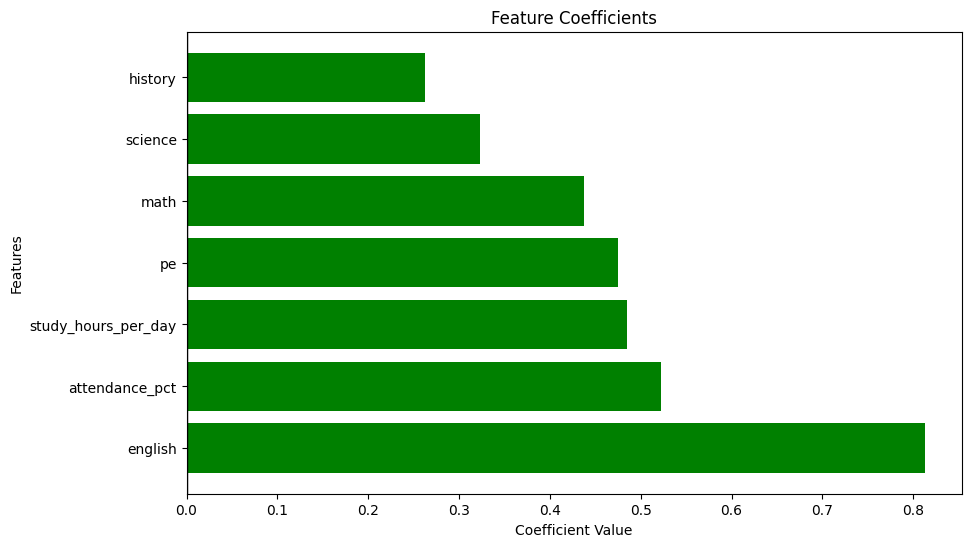


New Student Prediction: Pass
Prediction Probabilities: [[0.09203526 0.90796474]]


c:\Users\Shamith\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [23]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import pandas as pd

# Step 1 — Prepare Data
features = ['math', 'science', 'english', 'history', 'pe', 'attendance_pct', 'study_hours_per_day']
X = df[features]
y = df['passed']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 2 — Train a Model
model = LogisticRegression()
model.fit(X_train_scaled, y_train)
print(f"Training Accuracy: {model.score(X_train_scaled, y_train)}")

# Step 3 — Evaluate the Model
y_pred = model.predict(X_test_scaled)
print(f"Test Accuracy: {model.score(X_test_scaled, y_test)}")

test_names = df.loc[X_test.index, 'name']
for name, actual, pred in zip(test_names, y_test, y_pred):
    status = "✅ correct" if actual == pred else "❌ wrong"
    print(f"Student: {name}, Actual: {actual}, Predicted: {pred} {status}")

# Step 4 — Feature Importance
coefs = model.coef_[0]
importance_df = pd.DataFrame({'Feature': features, 'Coefficient': coefs})
importance_df['Abs_Value'] = importance_df['Coefficient'].abs()
importance_df = importance_df.sort_values(by='Abs_Value', ascending=False)

print("\nFeature Coefficients (Sorted by Absolute Value):")
print(importance_df[['Feature', 'Coefficient']])

plt.figure(figsize=(10, 6))
colors = ['green' if c > 0 else 'red' for c in importance_df['Coefficient']]
plt.barh(importance_df['Feature'], importance_df['Coefficient'], color=colors)
plt.title('Feature Coefficients')
plt.xlabel('Coefficient Value')
plt.ylabel('Features')
plt.axvline(0, color='black', lw=1)
plt.show()

# Step 5 — Predict for a New Student (Bonus)
new_student = [[75, 70, 68, 65, 80, 82, 3.2]]
new_student_scaled = scaler.transform(new_student)
prediction = model.predict(new_student_scaled)
probability = model.predict_proba(new_student_scaled)

print(f"\nNew Student Prediction: {'Pass' if prediction[0] == 1 else 'Fail'}")
print(f"Prediction Probabilities: {probability}")